# LSE ST451: Bayesian Machine Learning
## Author: Kostas Kalogeropoulos

## Week 3: Baysian Linear Regression part II

Topics covered 
 - Creating your own function in Python
 - Performing matrix operations
 - Conducting full MLE analysis, with confidence intervals rather than just point estimates for the regression coefficients
 - Fitting Bayesian Linear Regression models and summarising the posterior of the regressions coefficients
 - Calculate the marginal likelihood / model evidence for linear regression models to perform Bayesian model selection

We begin with loading the necessary libraries. We will pretty much the same libraries as next week with three additions: **scipy** for matrix operations, **seaborn** for better looking plots and **statsmodels** for full linear regression output

In [48]:
import numpy as np             
import pandas as pd  #Python Data Analysis Library handle data in a user friendly way
import scipy as sc
import matplotlib.pyplot as plt #for plots
import seaborn as sns # for better plots
%matplotlib inline
from sklearn import linear_model # A very popular Python library for Machine Learning
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split #needed to for assessing prediction
from sklearn import datasets ## imports datasets from scikit-learn
import statsmodels.api as sm

### Autmobile Bodily Injury Claims Data

Source: Insurance Research Council (IRC)

The data are automobile injury claims data using data from the Insurance Research Council (IRC), a division of the American Institute for Chartered Property Casualty Underwriters and the Insurance Institute of America. The data, collected in 2002, contains information on the gender of the claimant, attorney involvement, years of driving experience and the economic loss (LOSS, in thousands). A detailed description of the variables in the data is provided below:

- Attorney: Whether the claimant is represented by an attorney (=1 if yes and =0 if no)
- CLMSEX: Claimant’s gender (=1 if male and =0 if female 
- CLMAGE: Claimant’s age minus the age driving license was obtained
- LOSS: The claimant’s total economic loss (in thousands $)

For confidentiality issues we consider here a sample of  simulated data similar to that of a state is considered. 

The data are in the provided file 'automobileBI.csv'

In [49]:
data = pd.read_csv("automobileBI.csv") 
data.head()

,ATTORNEY,CLMSEX,CLMAGE,LOSS
0,1,0,1.8,6.38
1,0,0,5.6,0.95
2,1,1,1.4,1.88
3,0,1,5.4,0.11
4,1,0,0.9,6.95


In [50]:
data.describe()

,ATTORNEY,CLMSEX,CLMAGE,LOSS
count,1296.000000,1296.000000,1296.000000,1296.000000
mean,0.510802,0.423611,4.885571,4.616821
std,0.500076,0.494321,4.586972,7.570060
min,0.000000,0.000000,0.100000,0.010000
25%,0.000000,0.000000,1.700000,0.637500
50%,1.000000,0.000000,3.300000,2.000000
75%,1.000000,1.000000,6.600000,5.227500
max,1.000000,1.000000,31.300000,76.170000


KeyboardInterrupt: 

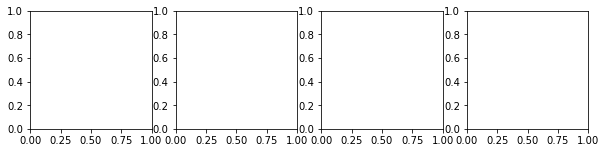

In [51]:
sns.pairplot(data)

Next we add x0 as a vector of ones for the constant in the regression equation. This will be handy for the matrix operations.

In [ ]:
n,p=data.shape
data['x0'] = np.ones(n)
data.head()

,ATTORNEY,CLMSEX,CLMAGE,LOSS,x0
0,1,0,1.8,6.38,1.0
1,0,0,5.6,0.95,1.0
2,1,1,1.4,1.88,1.0
3,0,1,5.4,0.11,1.0
4,1,0,0.9,6.95,1.0


### Matrix operations

Below we find the MLE without the scikit linear regression function. For that we

1. Form the design matrix $X$ and the response vector y
2. Calculate the MLE as $$\hat{\beta} = (X^T X)^{-1}X^T y$$

The code below does that and also prints $X^T X$ and $(X^T X)^{-1}$ for checking.

In [ ]:
predictors = ['x0','CLMAGE']
X = data[predictors]
y = data['LOSS']
XtX = X.T.dot(X) #X.T give X transpose X.dot(b) does matrix multiplication X*b
XtX_inv = sc.linalg.inv(XtX) #sc.linalg.inv(A) provide the inverse of A
beta = XtX_inv.dot(X.T.dot(y))
XtX, XtX_inv, beta

(            x0    CLMAGE
 x0      1296.0   6331.70
 CLMAGE  6331.7  58181.17,
 array([[ 1.64761435e-03, -1.79305432e-04],
        [-1.79305432e-04,  3.67010186e-05]]),
 array([ 4.85720385, -0.04920261]))

Check the MLE found previously with the scikit function

In [ ]:
linreg = LinearRegression()
predictors = ['CLMAGE']
linreg.fit(data[predictors],y)
beta = [linreg.intercept_]
beta.extend(linreg.coef_)
beta

[4.857203846578366, -0.04920261306845911]

We can go beyond the point estimate and calculate the variance of $\hat{\beta}$.

The code below provides $\hat{\sigma}^2$, the covariance matrix $$\mbox{var}[\hat{\beta}] = \hat{\sigma}^2 (X^T X)^{-1}, $$
and its diagonal.

In [ ]:
n,p = X.shape
e = y - X.dot(beta)
sigma2_hat = e.T.dot(e)/(n-p)
var_beta = sigma2_hat*(XtX_inv)
sigma2_hat, var_beta, np.diag(var_beta)

(57.299115791100185,
 array([[ 0.09440685, -0.01027404],
        [-0.01027404,  0.00210294]]),
 array([0.09440685, 0.00210294]))

With the above quantities we can calculate confidence intervals for MLE's. For those we will need the 97.5\% point of the $t_{n-p}$ distribution. 

The following code does that and also puts the results in pandas dataframe.

In [ ]:
#calculate 95% CI for beta and present output via a pandas data frame 
tval = sc.stats.t.ppf(0.975,n-p)
std_beta = np.sqrt(np.diag(var_beta))
lower95 = beta - tval*std_beta
upper95 = beta + tval*std_beta
results = np.column_stack([beta,std_beta,lower95,upper95])
col = ['coefficient','se','lower 95% bound','upper 95% bound']
ind = ['intercept','CLAMGE']
results = pd.DataFrame(results,columns = col,index=ind)
results

,coefficient,se,lower 95% bound,upper 95% bound
intercept,4.857204,0.307257,4.254427,5.459980
CLAMGE,-0.049203,0.045858,-0.139166,0.040761


To check our answers we also use the relevant function (.OLS) of the library **statsmodels**  

In [ ]:
predictors = ['CLMAGE']
X = data[predictors]
X = sm.add_constant(X) 
model = sm.OLS(y, X).fit()
model.summary()

c:\Users\19175\anaconda3\lib\site-packages\statsmodels\tsa\tsatools.py:142: FutureWarning: In a future version of pandas all arguments of concat except for the argument 'objs' will be keyword-only
  x = pd.concat(x[::order], 1)


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                   LOSS   R-squared:                       0.001
Model:                            OLS   Adj. R-squared:                  0.000
Method:                 Least Squares   F-statistic:                     1.151
Date:                Tue, 10 Feb 2026   Prob (F-statistic):              0.283
Time:                        14:19:04   Log-Likelihood:                -4461.2
No. Observations:                1296   AIC:                             8926.
Df Residuals:                    1294   BIC:                             8937.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          4.8572      0.307     15.808      0.000       4.254       5.460
CLMAGE        -0.0492      0.046     -1.073      0.283      -0.139       0.041
==============================================================================
Omnibus:                     1117.136   Durbin-Watson:                   1.954
Prob(Omnibus):                  0.000   Jarque-Bera (JB):            29065.564
Skew:                           3.999   Prob(JB):                         0.00
Kurtosis:                      24.778   Cond. No.                         9.91
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

### Activity 1

1. Obtain the MLEs and 95\% confidence intervals for the model with only the ATTORNEY variable and without using any Python built in function. 
2. Check your answers against the statsmodels corresponding function (.OLS)

In [ ]:
npower = 3
predictors = ['x0','ATTORNEY']
X = data[predictors]
y = data['LOSS']
XtX = X.T.dot(X) #X.T give X transpose X.dot(b) does matrix multiplication X*b
XtX_inv = sc.linalg.inv(XtX) #sc.linalg.inv(A) provide the inverse of A
beta = XtX_inv.dot(X.T.dot(y))
n,p = X.shape
e = y - X.dot(beta)
sigma2_hat = e.T.dot(e)/(n-p)
var_beta = sigma2_hat*(XtX_inv)
#calculate 95% CI for beta and present output via a pandas data frame 
tval = sc.stats.t.ppf(0.975,n-p)
std_beta = np.sqrt(np.diag(var_beta))
lower95 = beta - tval*std_beta
upper95 = beta + tval*std_beta
results = np.column_stack([beta,std_beta,lower95,upper95])
col = ['coefficient','se','lower 95% bound','upper 95% bound']
ind = ['intercept','ATTORNEY']
results = pd.DataFrame(results,columns = col,index=ind)
results

,coefficient,se,lower 95% bound,upper 95% bound
intercept,2.591356,0.290260,2.021925,3.160788
ATTORNEY,3.965260,0.406126,3.168523,4.761997


In [ ]:
predictors = ['ATTORNEY']
X = data[predictors]
X = sm.add_constant(X) 
model = sm.OLS(y, X).fit()
model.summary()

c:\Users\19175\anaconda3\lib\site-packages\statsmodels\tsa\tsatools.py:142: FutureWarning: In a future version of pandas all arguments of concat except for the argument 'objs' will be keyword-only
  x = pd.concat(x[::order], 1)


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                   LOSS   R-squared:                       0.069
Model:                            OLS   Adj. R-squared:                  0.068
Method:                 Least Squares   F-statistic:                     95.33
Date:                Tue, 10 Feb 2026   Prob (F-statistic):           8.91e-22
Time:                        14:24:24   Log-Likelihood:                -4415.7
No. Observations:                1296   AIC:                             8835.
Df Residuals:                    1294   BIC:                             8846.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          2.5914      0.290      8.928      0.000       2.022       3.161
ATTORNEY       3.9653      0.406      9.764      0.000       3.169       4.762
==============================================================================
Omnibus:                     1176.214   Durbin-Watson:                   1.936
Prob(Omnibus):                  0.000   Jarque-Bera (JB):            38690.889
Skew:                           4.233   Prob(JB):                         0.00
Kurtosis:                      28.393   Cond. No.                         2.64
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

### Writing functions in Python

We will now put all the previous talk into a function. In other words we will create our own function rather than using the stasmodels/scikit learn ones. 

The inputs of the function will be $X$, $y$ and the names of the predictors. The output will be a data frame with the results (MLE's, se's and 95\% CI's)  

In [ ]:
#create a function to get MLE of beta, its SE, 95%CIs and present the ouput  
def LRST451(X,y,predictor_names):
    col_names = ['beta','se','lower 95% bound','upper 95% bound']
    XtX = X.T.dot(X)
    XtX_inv = sc.linalg.inv(X.T.dot(X))
    beta = XtX_inv.dot(X.T.dot(y))
    e = y - X.dot(beta)
    n,p = X.shape
    sigma2_hat = e.T.dot(e)/(n-p)
    var_beta = sigma2_hat*(XtX_inv)
    tval = sc.stats.t.ppf(0.975,n-p)
    se_beta = np.sqrt(np.diag(var_beta))
    lower95 = beta - sc.stats.t.ppf(0.975,n-p)*se_beta
    upper95 = beta + sc.stats.t.ppf(0.975,n-p)*se_beta
    results = np.column_stack([beta,se_beta,lower95,upper95])
    results = pd.DataFrame(results,columns = col_names,index=predictor_names)
    return results

This is it, the function is now stored in Python's memory. 

From now on, we will only need to specify X,y predictor_names, and just write 'LRST451(X,y,predictor_names)'. 

In [ ]:
#Set up model (X) and y
predictors = ['x0','ATTORNEY']
X = data[predictors]
y = data['LOSS']
results = LRST451(X,y,predictors)
results

,beta,se,lower 95% bound,upper 95% bound
x0,2.591356,0.290260,2.021925,3.160788
ATTORNEY,3.965260,0.406126,3.168523,4.761997


### Bayesian Linear Regression

We now turn to Bayesian inference. As before we will illustrate and then create a function that provides summaries of the posterior (Bayes estimates of $\beta$ and 95\% Credible Intervals).

We start by calculating the posterior parameters that correspond to the unit information prior.

Given $\sigma^2$ and a **prior** of N($\mu_0,\sigma^2\Omega_0)$, the **posterior** $\pi(\beta|X,y,\sigma^2)$ is N($\mu_n,\sigma^2\Omega_n^2$) where

$$\mu_n = (X^T X+\Omega_0^{-1})^{-1} (\Omega_0^{-1}\mu_0 +X^{T}y)$$
$$\Omega_n =(X^T X +\Omega_0^{-1})^{-1}$$

To assign the unit information prior we set $\Omega_0 = n(X^T X)^{-1}$ or else $\Omega_0^{-1}=X^T X / n$.

For $\sigma^2$ if we set the **prior** IGamma$(a_0,b_0)$ we get the **posterior** IGamma$(a_n,b_n)$ where
$$
a_n = a_0+\frac{n}{2}
$$
$$
b_n = b_0+\frac{1}{2} (y^T y + \mu_0^T\Omega_0^{-1}\mu_0 +\mu_n^T\Omega_n^{-1}\mu_n).
$$

In [ ]:
#set up X and y
predictors = ['x0','CLMAGE']
X = data[predictors]
y = data['LOSS']
n,p = X.shape

#set up prior parameters
mu_0 = np.zeros(p)
XtX = X.T.dot(X)
Om_0_inv = XtX/n #unit information prior
a_0 = 0.01
b_0 = 0.01

#calculate posterior parameters
Om_n_inv = XtX + Om_0_inv
Om_n = sc.linalg.inv(Om_n_inv)
term1 = Om_0_inv.dot(mu_0)+X.T.dot(y)
mu_n = Om_n.dot(term1)
a_n = a_0 + n/2
term2 = y.T.dot(y)+mu_0.dot(Om_0_inv.dot(mu_0))+mu_n.dot(Om_n_inv.dot(mu_n))
b_n = b_0 + term2/2

#### Monte Carlo for credible intervals

To obtain credible intervals for $\beta$ we could use the $t$ distribution. But we would use Monte Carlo instead as this will cover more general models. e.g. logistic regression.

So we will sample $N$ Monte Carlo samples from $\pi(\beta|y)$ and use them  for Monte Carlo inference (credible intervals, density plots etc)

Monte Carlo Samples can be drawn by

1. Generating samples $\sigma_i^2$ from IGamma$(\alpha_n,\beta_n)$, $i=1,\dots,N$,
2. Draw $\beta_i$ sample based on each $\sigma_i^2$ from N($\mu_n,\sigma_i^2\Omega_n^2$)

In [ ]:
#Calculate 95% credible intervals
N = 10000 #number of Monte Carlo samples
n,p = X.shape
sigma2 = 1/np.random.gamma(a_n, 1/b_n, N)
betas = np.zeros((N,p))
# draw N samples from the marginal posterior of beta
for i in range(0,N):
    s2 =sigma2[i]
    cov = s2*Om_n
    betas[i,] = np.random.multivariate_normal(mu_n,cov,1)

#find the mean of each column which corresponds to each beta coefficient     
mu_beta = np.mean(betas, axis=0)
#find the 2.5 and 97.5 percentils which correspond to each beta coefficient 
lower95 = np.percentile(betas,2.5,axis=0)
upper95 = np.percentile(betas,97.5,axis=0)
mu_beta, lower95, upper95

(array([ 4.85442634, -0.04890711]),
 array([ 4.06641393, -0.16573107]),
 array([5.65445701, 0.06967852]))

As before we put it all in a function. This is quite handy as it is hard to find such a function in Python!!

In [ ]:
# function for Bayesian Linear regression, return posterior mean and 95% CIs
def BLR(X,y,mu_0,Om_0_inv,a_0,b_0,ind_names,N):
    col_names = ['posterior mean','lower 95% bound','upper 95% bound']
    n,p = X.shape
    XtX = X.T.dot(X)
    Om_n_inv = XtX + Om_0_inv
    Om_n = sc.linalg.inv(Om_n_inv)
    term1 = Om_0_inv.dot(mu_0)+X.T.dot(y)
    mu_n = Om_n.dot(term1)
    a_n = a_0 + n/2
    term2 = y.T.dot(y)+mu_0.dot(Om_0_inv.dot(mu_0))+mu_n.dot(Om_n_inv.dot(mu_n))
    b_n = b_0 + term2/2
    sigma2 = 1/np.random.gamma(a_n, 1/b_n, N)
    betas = np.zeros((N,p))
    # draw N samples from the marginal posterior of beta
    for i in range(0,N):
        s2 =sigma2[i]
        cov = s2*Om_n
        betas[i,] = np.random.multivariate_normal(mu_n,cov,1)

    #find the mean of each column which corresponds to each beta coefficient     
    mu_beta = np.mean(betas, axis=0)
    #find the 2.5 and 97.5 percentils which correspond to each beta coefficient 
    lower95 = np.percentile(betas,2.5,axis=0)
    upper95 = np.percentile(betas,97.5,axis=0)
    results = np.column_stack([mu_beta,lower95,upper95])
    results = pd.DataFrame(results,columns = col_names,index=ind_names)
    return results, mu_n, Om_n, a_n, b_n

Now we only need to spefcify the data and the prior parameters and input them to the BLR function. 

We will get back a pandas dataframe with the results.

In [ ]:
predictors = ['x0','CLMAGE']
X = data[predictors]
y = data['LOSS']
n,p = X.shape

#set up prior parameters
mu_0 = np.zeros(p)
XtX = X.T.dot(X)
Om_0_inv = XtX/n #unit information prior
a_0 = 0.01
b_0 = 0.01

N=10000 #Monte Carlo sample size

results, mu_n, Om_n, a_n, b_n = BLR(X,y,mu_0,Om_0_inv,a_0,b_0,predictors,N)
results

,posterior mean,lower 95% bound,upper 95% bound
x0,4.855166,4.058788,5.652718
CLMAGE,-0.049909,-0.166604,0.068494


Compare with the frequentist model results

In [ ]:
LRST451(X,y,predictors)

,beta,se,lower 95% bound,upper 95% bound
x0,4.857204,0.307257,4.254427,5.459980
CLMAGE,-0.049203,0.045858,-0.139166,0.040761


### Marginal likelihood / Model Evidence

Finally we will calculate the marginal likelihood / model evidence of a given model. We will use the following trick covered in the lecture

We can write
$$
\pi(\beta,\sigma^2|y,X)=\frac{\pi(y|\beta,\sigma^2,X)\pi(\beta,\sigma^2)}{\pi(y|X)},
$$
or else
$$
\pi(y|X)=\frac{\pi(y|\beta,\sigma^2,X)\pi(\beta,\sigma^2)}{\pi(\beta,\sigma^2|y,X)},
$$
for all $\beta, \sigma^2$.

The expression above contains known Normal and Inverse Gamma pdfs so we can just evaluate for -say- the posterior mean of $\beta$, $\sigma^2$.

The calculation involves the following steps

1. Specify data and prior
2. get the parameters of the posteriod distribution
3. evaluate the log-likelihood, log-prior and log-posterior at the posterior mean
4. The log-evidence is equal to log-likelihood + log-prior - log-posterior


In [ ]:
# Step 1
predictors = ['x0','CLMAGE']
X = data[predictors]
y = data['LOSS']
n,p = X.shape

# Step 2
mu_0 = np.zeros(p)
XtX = X.T.dot(X)
Om_0_inv = XtX/n #unit information prior
a_0 = 0.01
b_0 = 0.01
N=10000 #Monte Carlo sample size
results, mu_n, Om_n, a_n, b_n = BLR(X,y,mu_0,Om_0_inv,a_0,b_0,predictors,N)

# Step 3
# evaluate log-likelihood
beta = mu_n
sigma2 = b_n/(a_n-1)
Om_0 = sc.linalg.inv(Om_0_inv)
mu = X.dot(beta)
cov = sigma2*np.eye(n)
ll = sc.stats.multivariate_normal.logpdf(y,mu,cov)
# evaluate log-prior
lprior = a_0*np.log(b_0)-sc.special.loggamma(a_0)- (a_0+1)*np.log(sigma2)-b_0/sigma2
lprior = lprior + sc.stats.multivariate_normal.logpdf(beta,mu_0,sigma2*Om_0)
# evaluate log-posterior
lpost = a_n*np.log(b_n)-sc.special.loggamma(a_n)- (a_n+1)*np.log(sigma2)-b_n/sigma2
lpost = lpost + sc.stats.multivariate_normal.logpdf(beta,mu_n,sigma2*Om_n)

lmodevid = ll+lprior-lpost
lmodevid 

-4560.3222464004775

Let's make it a function. Again not easy to find such a function, keep it!

In [ ]:
def ModEvidence(X,y,mu_n,Om_n,mu_0,Om_0_inv,a_n,b_n,a_0,b_0): 
    #set beta and sigma2 to their posterior mean 
    beta = mu_n
    sigma2 = b_n/(a_n-1)
    Om_0 = sc.linalg.inv(Om_0_inv)
    mu = X.dot(beta)
    cov = sigma2*np.eye(X.shape[0])
    ll = sc.stats.multivariate_normal.logpdf(y,mu,cov)
    # evaluate log-prior
    lprior = a_0*np.log(b_0)-sc.special.loggamma(a_0)- (a_0+1)*np.log(sigma2)-b_0/sigma2
    lprior = lprior + sc.stats.multivariate_normal.logpdf(beta,mu_0,sigma2*Om_0)
    # evaluate log-posterior
    lpost = a_n*np.log(b_n)-sc.special.loggamma(a_n)- (a_n+1)*np.log(sigma2)-b_n/sigma2
    lpost = lpost +sc.stats.multivariate_normal.logpdf(beta,mu_n,sigma2*Om_n)
    lmodevid = ll+lprior-lpost
    return lmodevid

Now to get the evidence for a model we can simply use the code below

In [ ]:
# Data
predictors = ['x0','CLMAGE']
X = data[predictors]
y = data['LOSS']
n,p = X.shape

# Prior
mu_0 = np.zeros(p)
XtX = X.T.dot(X)
Om_0_inv = XtX/n #unit information prior
a_0 = 0.01
b_0 = 0.01

# Calculation
N=10000 #Monte Carlo sample size
results, mu_n, Om_n, a_n, b_n = BLR(X,y,mu_0,Om_0_inv,a_0,b_0,predictors,N)
lmodevid = ModEvidence(X,y,mu_n,Om_n,mu_0,Om_0_inv,a_n,b_n,a_0,b_0)
lmodevid

-4560.3222464004775

### Activity 2

Consider all possible regression models with the LOSS variable as response and some (or all or none) of the other variables present (in their current form, no polynomials). There are 8 such models.

Calculate the model evidence for each of them, report the optimal one and present posterior estimates of its coefficients.

In [ ]:
'''
The models are:
1. Intercept  only
2. Intercept & ATTORNEY
3. Intercept & CLMSEX
4. Intercept & CLMAGE
5. Intercept & ATTORNEY & CLMSEX
6. Intercept & ATTORNEY & CLMAGE
7. Intercept & CLMSEX & CLMAGE
8. Intercept & ATTORNEY & CLMSEX & CLMAGE
'''

#  across models
N = 10000 # Set Monte Carlo sample size
n = data.shape[0]
y = data['LOSS']
#Priors constant across models
a_0 = 0.01
b_0 = 0.01

In [ ]:
# Model 1
predictors = ['x0']
X = data[predictors]

n,p = X.shape

#Prior depending on X
mu_0 = np.zeros(p)
XtX = X.T.dot(X)
Om_0_inv = XtX/n #unit information prior

np.random.seed(1)
results, mu_n, Om_n, a_n, b_n = BLR(X,y,mu_0,Om_0_inv,a_0,b_0,predictors,N)
log_evid= ModEvidence(X,y,mu_n,Om_n,mu_0,Om_0_inv,a_n,b_n,a_0,b_0)
print(log_evid)   #M1 -4556
print(results)

-4556.926600461306
    posterior mean  lower 95% bound  upper 95% bound
x0        4.611626          4.07087         5.157655


In [ ]:
#Model 2
predictors = ['x0','ATTORNEY']
X = data[predictors]
n,p = X.shape

#Prior depending on X
mu_0 = np.zeros(p)
XtX = X.T.dot(X)
Om_0_inv = XtX/n #unit information prior

results, mu_n, Om_n, a_n, b_n = BLR(X,y,mu_0,Om_0_inv,a_0,b_0,predictors,N)
log_evid= ModEvidence(X,y,mu_n,Om_n,mu_0,Om_0_inv,a_n,b_n,a_0,b_0)
print(log_evid)   #M2 -4546
print(results)

-4546.989745668816
          posterior mean  lower 95% bound  upper 95% bound
x0              2.592037         1.782266         3.389313
ATTORNEY        3.958257         2.844008         5.063022


In [ ]:
#Model 3
predictors = ['x0','CLMSEX']
X = data[predictors]
n,p = X.shape

#Prior depending on X
mu_0 = np.zeros(p)
XtX = X.T.dot(X)
Om_0_inv = XtX/n #unit information prior

results, mu_n, Om_n, a_n, b_n = BLR(X,y,mu_0,Om_0_inv,a_0,b_0,predictors,N)
log_evid= ModEvidence(X,y,mu_n,Om_n,mu_0,Om_0_inv,a_n,b_n,a_0,b_0)
print(log_evid)   #M3 -4560
print(results)

-4560.446954415578
        posterior mean  lower 95% bound  upper 95% bound
x0            4.725549         4.010389         5.444128
CLMSEX       -0.257084        -1.378308         0.842691


In [ ]:
#Model 4
predictors = ['x0','CLMAGE']
X = data[predictors]
n,p = X.shape

#Prior depending on X
mu_0 = np.zeros(p)
XtX = X.T.dot(X)
Om_0_inv = XtX/n #unit information prior


results, mu_n, Om_n, a_n, b_n = BLR(X,y,mu_0,Om_0_inv,a_0,b_0,predictors,N)
log_evid= ModEvidence(X,y,mu_n,Om_n,mu_0,Om_0_inv,a_n,b_n,a_0,b_0)
print(log_evid)   #M4 -4560
print(results) 

-4560.3222464004775
        posterior mean  lower 95% bound  upper 95% bound
x0            4.851064         4.065270         5.641037
CLMAGE       -0.048321        -0.165838         0.068662


In [ ]:
#Model 5
predictors = ['x0','ATTORNEY','CLMSEX']
X = data[predictors]
n,p = X.shape

#Prior depending on X
mu_0 = np.zeros(p)
XtX = X.T.dot(X)
Om_0_inv = XtX/n #unit information prior


results, mu_n, Om_n, a_n, b_n = BLR(X,y,mu_0,Om_0_inv,a_0,b_0,predictors,N)
log_evid= ModEvidence(X,y,mu_n,Om_n,mu_0,Om_0_inv,a_n,b_n,a_0,b_0)
print(log_evid)   #M1 -4550
print(results)

-4550.036219168243
          posterior mean  lower 95% bound  upper 95% bound
x0              2.885381         2.003162         3.755678
ATTORNEY        4.074222         2.960213         5.191702
CLMSEX         -0.843058        -1.975855         0.297726


In [ ]:
#Model 6
predictors = ['x0','ATTORNEY','CLMAGE']
X = data[predictors]
n,p = X.shape

#Prior depending on X
mu_0 = np.zeros(p)
XtX = X.T.dot(X)
Om_0_inv = XtX/n #unit information prior


results, mu_n, Om_n, a_n, b_n = BLR(X,y,mu_0,Om_0_inv,a_0,b_0,predictors,N)
log_evid= ModEvidence(X,y,mu_n,Om_n,mu_0,Om_0_inv,a_n,b_n,a_0,b_0)
print(log_evid)   #M1 -4550
print(results)

-4550.538073983398
          posterior mean  lower 95% bound  upper 95% bound
x0              2.716994         1.728447         3.700488
ATTORNEY        3.948569         2.837652         5.063581
CLMAGE         -0.023937        -0.142927         0.094724


In [ ]:
#Model 7
predictors = ['x0','CLMSEX','CLMAGE']
X = data[predictors]
n,p = X.shape

#Prior depending on X
mu_0 = np.zeros(p)
XtX = X.T.dot(X)
Om_0_inv = XtX/n #unit information prior


results, mu_n, Om_n, a_n, b_n = BLR(X,y,mu_0,Om_0_inv,a_0,b_0,predictors,N)
log_evid= ModEvidence(X,y,mu_n,Om_n,mu_0,Om_0_inv,a_n,b_n,a_0,b_0)
print(log_evid)   #M1 -4563
print(results)

-4563.83124291686
        posterior mean  lower 95% bound  upper 95% bound
x0            4.989503         4.058660         5.925917
CLMSEX       -0.294295        -1.429375         0.789711
CLMAGE       -0.051584        -0.168243         0.067790


In [ ]:
#Model 8
predictors = ['x0','ATTORNEY','CLMSEX','CLMAGE']
X = data[predictors]
n,p = X.shape

#Prior depending on X
mu_0 = np.zeros(p)
XtX = X.T.dot(X)
Om_0_inv = XtX/n #unit information prior


results, mu_n, Om_n, a_n, b_n = BLR(X,y,mu_0,Om_0_inv,a_0,b_0,predictors,N)
log_evid= ModEvidence(X,y,mu_n,Om_n,mu_0,Om_0_inv,a_n,b_n,a_0,b_0)
print(log_evid)   #M1 -4553
print(results) 

-4553.572305380252
          posterior mean  lower 95% bound  upper 95% bound
x0              3.025702         1.914146         4.135475
ATTORNEY        4.063102         2.937584         5.189575
CLMSEX         -0.847950        -1.994700         0.311932
CLMAGE         -0.025824        -0.148332         0.096406


Model 2 has the highest evidence (-4546). So information about gender does not appear to essential.

### Activity 3

Given that the scatter plots do not provide support for the linear model, consider transforming the target and/or the features and repeat.


Put your code below

In [ ]:
data['logloss'] = np.log(data['LOSS'])
data['logage'] = np.log(data['CLMAGE'])

In [ ]:
predictors = ['ATTORNEY','CLMSEX','logage','logloss']
data2 = data[predictors]

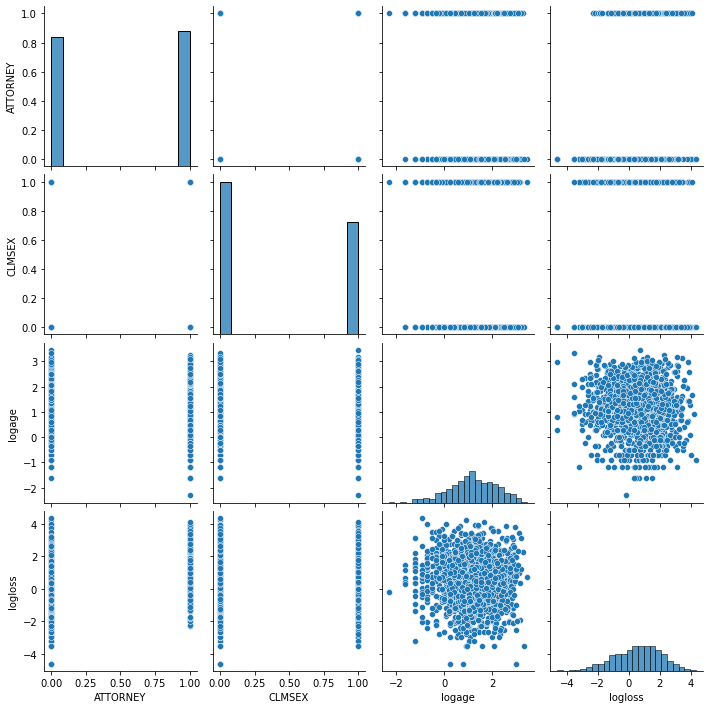

In [ ]:
sns.pairplot(data2)

In [ ]:
data2['x0'] = np.ones(n)
data2

C:\Users\19175\AppData\Local\Temp/ipykernel_28276/1157019097.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data2['x0'] = np.ones(n)


,ATTORNEY,CLMSEX,logage,logloss,x0
0,1,0,0.587787,1.853168,1.0
1,0,0,1.722767,-0.051293,1.0
2,1,1,0.336472,0.631272,1.0
3,0,1,1.686399,-2.207275,1.0
4,1,0,-0.105361,1.938742,1.0
...,...,...,...,...,...
1291,1,0,0.262364,0.978326,1.0
1292,0,1,0.587787,-1.771957,1.0
1293,1,0,2.727853,1.286474,1.0
1294,1,1,1.547563,0.431782,1.0


In [ ]:
#  across models
N = 10000 # Set Monte Carlo sample size
n = data2.shape[0]
y = data['logloss']
#Priors constant across models
a_0 = 0.01
b_0 = 0.01

In [ ]:
predictors = ['x0']
X = data2[predictors]

n,p = X.shape

#Prior depending on X
mu_0 = np.zeros(p)
XtX = X.T.dot(X)
Om_0_inv = XtX/n #unit information prior
results, mu_n, Om_n, a_n, b_n = BLR(X,y,mu_0,Om_0_inv,a_0,b_0,predictors,N)
log_evid= ModEvidence(X,y,mu_n,Om_n,mu_0,Om_0_inv,a_n,b_n,a_0,b_0)
print(log_evid)   #M1 -2398
print(results)

-2398.0683194345474
    posterior mean  lower 95% bound  upper 95% bound
x0        0.577458         0.485494          0.67045


In [ ]:
predictors = ['x0','ATTORNEY']
X = data2[predictors]

n,p = X.shape

#Prior depending on X
mu_0 = np.zeros(p)
XtX = X.T.dot(X)
Om_0_inv = XtX/n #unit information prior
results, mu_n, Om_n, a_n, b_n = BLR(X,y,mu_0,Om_0_inv,a_0,b_0,predictors,N)
log_evid= ModEvidence(X,y,mu_n,Om_n,mu_0,Om_0_inv,a_n,b_n,a_0,b_0)
print(log_evid)   #M1 -2337
print(results)

-2337.250419698611
          posterior mean  lower 95% bound  upper 95% bound
x0             -0.138933        -0.283246         0.003241
ATTORNEY        1.404288         1.204475         1.602488


In [ ]:
predictors = ['x0','logage']
X = data2[predictors]

n,p = X.shape

#Prior depending on X
mu_0 = np.zeros(p)
XtX = X.T.dot(X)
Om_0_inv = XtX/n #unit information prior
results, mu_n, Om_n, a_n, b_n = BLR(X,y,mu_0,Om_0_inv,a_0,b_0,predictors,N)
log_evid= ModEvidence(X,y,mu_n,Om_n,mu_0,Om_0_inv,a_n,b_n,a_0,b_0)
print(log_evid)   #M1 -2399
print(results)

-2399.7163108136397
        posterior mean  lower 95% bound  upper 95% bound
x0            0.707429         0.561871         0.857826
logage       -0.111268        -0.208669        -0.013443


In [ ]:
predictors = ['x0','CLMSEX']
X = data2[predictors]

n,p = X.shape

#Prior depending on X
mu_0 = np.zeros(p)
XtX = X.T.dot(X)
Om_0_inv = XtX/n #unit information prior
results, mu_n, Om_n, a_n, b_n = BLR(X,y,mu_0,Om_0_inv,a_0,b_0,predictors,N)
log_evid= ModEvidence(X,y,mu_n,Om_n,mu_0,Om_0_inv,a_n,b_n,a_0,b_0)
print(log_evid)   #M1 -2401
print(results)

-2401.568289166891
        posterior mean  lower 95% bound  upper 95% bound
x0            0.559142         0.434713         0.680685
CLMSEX        0.045677        -0.141679         0.232048


In [ ]:
predictors = ['x0','ATTORNEY','CLMSEX']
X = data2[predictors]

n,p = X.shape

#Prior depending on X
mu_0 = np.zeros(p)
XtX = X.T.dot(X)
Om_0_inv = XtX/n #unit information prior
results, mu_n, Om_n, a_n, b_n = BLR(X,y,mu_0,Om_0_inv,a_0,b_0,predictors,N)
log_evid= ModEvidence(X,y,mu_n,Om_n,mu_0,Om_0_inv,a_n,b_n,a_0,b_0)
print(log_evid)   #M1 -2340
print(results)

-2340.2691342053026
          posterior mean  lower 95% bound  upper 95% bound
x0             -0.084116        -0.240793         0.076911
ATTORNEY        1.426089         1.220868         1.627708
CLMSEX         -0.156458        -0.364838         0.047767


In [ ]:
predictors = ['x0','ATTORNEY','logage']
X = data2[predictors]

n,p = X.shape

#Prior depending on X
mu_0 = np.zeros(p)
XtX = X.T.dot(X)
Om_0_inv = XtX/n #unit information prior
results, mu_n, Om_n, a_n, b_n = BLR(X,y,mu_0,Om_0_inv,a_0,b_0,predictors,N)
log_evid= ModEvidence(X,y,mu_n,Om_n,mu_0,Om_0_inv,a_n,b_n,a_0,b_0)
print(log_evid)   #M1 -2340
print(results)

-2340.601021623488
          posterior mean  lower 95% bound  upper 95% bound
x0             -0.077655        -0.273628         0.118189
ATTORNEY        1.397929         1.193406         1.601538
logage         -0.050852        -0.157048         0.053112


In [ ]:
predictors = ['x0','CLMSEX','logage']
X = data2[predictors]

n,p = X.shape

#Prior depending on X
mu_0 = np.zeros(p)
XtX = X.T.dot(X)
Om_0_inv = XtX/n #unit information prior
results, mu_n, Om_n, a_n, b_n = BLR(X,y,mu_0,Om_0_inv,a_0,b_0,predictors,N)
log_evid= ModEvidence(X,y,mu_n,Om_n,mu_0,Om_0_inv,a_n,b_n,a_0,b_0)
print(log_evid)   #M1 -2403
print(results)

-2403.265669655174
        posterior mean  lower 95% bound  upper 95% bound
x0            0.692220         0.520113         0.866644
CLMSEX        0.028874        -0.159609         0.217755
logage       -0.109604        -0.206238        -0.013802


In [ ]:
predictors = ['x0','ATTORNEY','logage','CLMSEX']
X = data2[predictors]

n,p = X.shape

#Prior depending on X
mu_0 = np.zeros(p)
XtX = X.T.dot(X)
Om_0_inv = XtX/n #unit information prior
results, mu_n, Om_n, a_n, b_n = BLR(X,y,mu_0,Om_0_inv,a_0,b_0,predictors,N)
log_evid= ModEvidence(X,y,mu_n,Om_n,mu_0,Om_0_inv,a_n,b_n,a_0,b_0)
print(log_evid)   #M1 -2343
print(results)

-2343.5723554256792
          posterior mean  lower 95% bound  upper 95% bound
x0             -0.010936        -0.220712         0.198080
ATTORNEY        1.417957         1.213330         1.622282
logage         -0.057472        -0.163497         0.045900
CLMSEX         -0.163018        -0.369495         0.041705


Same conclusion as before. Model 2 has the highest evidence (-2337). So information about gender does not appear to essential.